## Instructions:
1. Rename this file with your roll number in the placeholder (e.g., MT24003_a1.py).
2. Extract the provided data.zip folder next to this file.
3. Do NOT install or import any additional libraries.
4. Complete only the sections marked with `# YOUR CODE HERE`.

## Library Imports

In [172]:
# Allowed imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import cv2
import random
import time

## Random Number Generator
Generate pseudo-random numbers using a custom implementation. This function must generate random numbers WITHOUT using Python's `random` module or `np.random`. Instead, a deterministic pseudo-random process should be implemented using arithmetic operations and an optional seed for reproducibility.

### Code

In [173]:
class LinearCongruentialGenerator:
    def __init__(self, seed=None):
        # Parameters for the LCG
        self.m = 2**31
        self.a = 1103515245
        self.c = 12345
        
        if seed is None:
            seed = int(time.time()) % self.m
        self.state = seed % self.m

    def next(self):
        self.state = (self.a * self.state + self.c) % self.m
        return self.state / self.m  # Normalize to [0, 1)
    
class BoxMullerTransform:
    def __init__(self, lcg):
        self.lcg = lcg
        self.has_spare = False
        self.spare = 0.0

    def next(self):
        if self.has_spare:
            self.has_spare = False
            return self.spare
        
        u1 = self.lcg.next()
        u2 = self.lcg.next()
        
        r = np.sqrt(-2.0 * np.log(u1))
        theta = 2.0 * np.pi * u2
        
        z0 = r * np.cos(theta)
        z1 = r * np.sin(theta)
        
        self.spare = z1
        self.has_spare = True
        
        return z0

def generate_random_numbers(shape, distribution="gaussian", seed=None):
    """
    The function should support both uniform and Gaussian distributions.

    Args:
        shape (int or tuple of ints):
            Desired shape of the output.
            - If int, return a list of length `shape`
            - If tuple, return nested lists with that shape
        distribution (str):
            Type of distribution to generate.
            Supported values: "uniform", "gaussian".
        seed (int, optional):
            Seed value to ensure reproducibility. If None, the seed
            may be derived from the current time.

    Returns:
        list:
            Random numbers shaped according to `shape`.
            Values should lie in:
            - [0, 1) for uniform distribution
            - approximately zero mean and unit variance for Gaussian
    """
    # YOUR CODE HERE

    
    lcg = LinearCongruentialGenerator(seed)
    
    if(distribution == "uniform"):
        generator = lcg.next
    elif(distribution == "gaussian"):
        bmt = BoxMullerTransform(lcg)
        generator = bmt.next
    else:
        print("Not a valid supported distribution")

    # Recursive helper to handle arbitrary tuple shapes
    def fill_shape(shape):
        if (isinstance(shape, int)):
            result = []
            for _ in range(shape):
                result.append(generator())
            return result
        
        head, *tail = shape
        result = []
        for _ in range(head):
            if tail:
                result.append(fill_shape(tuple(tail)))
            else:
                result.append(generator())
        return result

    return fill_shape(shape)
        

### Visualize and Plot

STANDARD DEVIATION OF UNIFORM RV :  0.2893403050352392
STANDARD DEVIATION OF GAUSSIAN RV :  1.0054015654654491
MEAN OF UNIFORM RV :  0.49838059948422014
MEAN OF GAUSSIAN RV :  0.014185598879385818


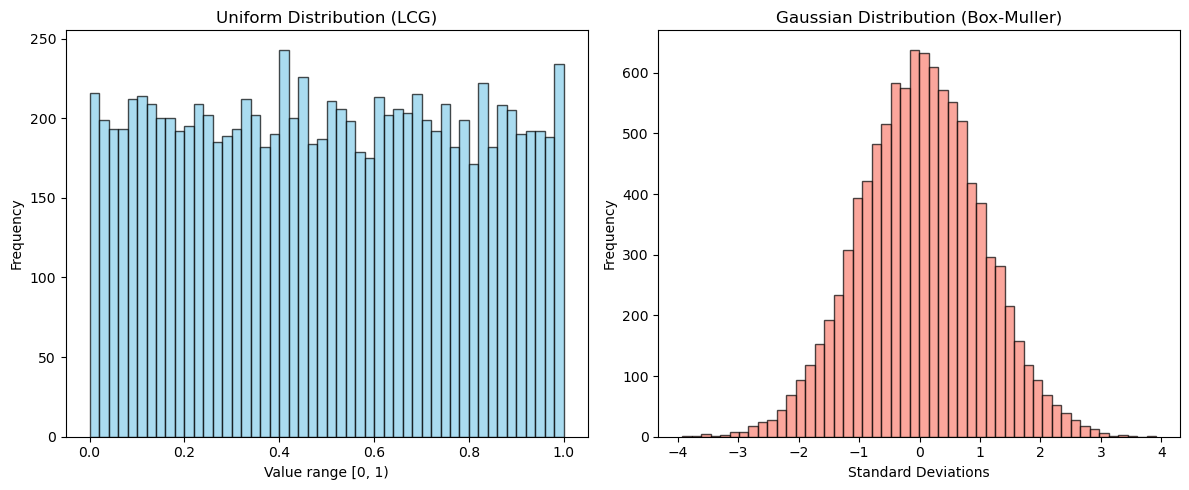

In [205]:
# YOUR CODE HERE

n_samples = 10000
uniform_data = generate_random_numbers(n_samples, distribution="uniform", seed=42)
gaussian_data = generate_random_numbers(n_samples, distribution="gaussian", seed=42)
print("STANDARD DEVIATION OF UNIFORM RV : ", np.std(uniform_data))
print("STANDARD DEVIATION OF GAUSSIAN RV : ", np.std(gaussian_data))
print("MEAN OF UNIFORM RV : ", np.mean(uniform_data))
print("MEAN OF GAUSSIAN RV : ", np.mean(gaussian_data))

plt.figure(figsize=(12, 5))

# Plot Uniform
plt.subplot(1, 2, 1)
plt.hist(uniform_data, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Uniform Distribution (LCG)')
plt.xlabel('Value range [0, 1)')
plt.ylabel('Frequency')

# Plot Gaussian
plt.subplot(1, 2, 2)
plt.hist(gaussian_data, bins=50, color='salmon', edgecolor='black', alpha=0.7)
plt.title('Gaussian Distribution (Box-Muller)')
plt.xlabel('Standard Deviations')
plt.ylabel('Frequency')

plt.tight_layout()

### Usecase of Pseudo Random Generator
This function is used to initialise weights of different models or data sampling



## Image Loader

In [175]:
def load_image(path_to_image_file):
    """
    Load an image from disk and return it as an RGB NumPy array.

    This function must:
    1. Read the image from disk
    2. Ensure the image has exactly 3 channels
    3. Convert the channel order to RGB

    Args:
        path_to_image_file (str): Path to the image file.

    Returns:
        np.ndarray:
            Image array of shape (H, W, 3) in RGB format.
    """
    # YOUR CODE HERE
    obj_image = cv2.imread(path_to_image_file, cv2.IMREAD_COLOR)
    obj_image = cv2.cvtColor(obj_image, cv2.COLOR_BGR2RGB)
    return obj_image

## Image Functions

In [176]:
def inspect_image(image):
    """
    Inspect numerical and memory properties of an image array.

    Args:
        image (np.ndarray): Input image array.

    Returns:
        dict with keys:
        - shape
        - dtype
        - min
        - max
        - KB
        - MB
    """
    # YOUR CODE HERE
    img_shape = image.shape
    img_dtype = image.dtype
    min_val = np.min(image)
    max_val = np.max(image)
    size_bytes = image.nbytes
    size_kb = size_bytes / 1024
    size_mb = size_kb / 1024

    result = {};
    result['shape'] = img_shape
    result['dtype'] = img_dtype
    result['min'] = min_val
    result['max'] = max_val
    result['KB'] = size_kb
    result['MB'] = size_mb
    return result

In [177]:
def min_max_normalize(image):
    """
    Apply min-max normalization to an image.

    Args:
        image (np.ndarray): Input image.

    Returns:
        np.ndarray: Normalized image with values in [0, 1].
    """
    # YOUR CODE HERE
    max_val = np.max(image)
    min_val = np.min(image)
    norm_img = (image - min_val) / (max_val - min_val)
    return norm_img


In [178]:
def standardize(image, mean=0, std=1):
    """
    Standardize image pixel values using a specified mean and standard deviation.

    Args:
        image (np.ndarray): Input image.
        mean (float): Desired mean of the standardized output.
        std (float): Desired standard deviation of the standardized output.

    Returns:
        np.ndarray: Standardized image array.
    """
    # YOUR CODE HERE
    true_mean = np.mean(image)
    true_std = np.std(image)
    std_img = (image - true_mean)/true_std
    std_img = (std_img * std) + mean
    return std_img

In [179]:
def crop_image(image, top, left, height, width):
    """
    Crop a rectangular region from an image using NumPy slicing.

    This function should return a view (not a copy) of the original image
    whenever possible, demonstrating how NumPy handles memory efficiently.

    Args:
        image (np.ndarray):
            Input image.
        top, left (int):
            Top-left corner of the crop.
        height, width (int):
            Size of the cropped region.

    Returns:
        np.ndarray:
            Cropped image.
    """
    # YOUR CODE HERE
    cropped_img = image[top:top+height, left:left+width]
    return cropped_img

In [180]:
def resize_with_padding(image, target_size=(224, 224)):
    """
    Resize an image to a fixed target size while preserving aspect ratio.

    The image should be resized such that its aspect ratio is preserved.
    Any remaining area should be padded with zeros (black pixels) to
    achieve the target size.

    This function must work for both:
    - Color images of shape (H, W, 3)
    - Grayscale images of shape (H, W)

    Args:
        image (np.ndarray): Input image as a NumPy array.
        target_size (tuple): Desired output size as (height, width).
            Default is (224, 224).

    Returns:
        np.ndarray: Resized image of shape:
            - (224, 224, 3) for color images
            - (224, 224) for grayscale images
    """
    # YOUR CODE HERE
    target_height = target_size[0]
    target_width = target_size[1]

    original_height = image.shape[0]
    original_width = image.shape[1]

    scale = min(target_width / original_width, target_height / original_height)
    
    resized_height = int(original_height * scale)
    resized_width = int(original_width * scale)

    resized_image = cv2.resize(image, (resized_width, resized_height))

    if(image.ndim == 3):
        final_image = np.zeros((target_height, target_width, 3), dtype=image.dtype)
    else:
        final_image = np.zeros((target_height, target_width), dtype=image.dtype)

    y_off = (target_height - resized_height) // 2
    x_off = (target_width - resized_width) // 2

    final_image[y_off : y_off + resized_height, x_off : x_off + resized_width] = resized_image
    return final_image


In [181]:
def extract_rgb_channels(image):
    """Extract R, G, B channels."""
    # YOUR CODE HERE
    blue, green, red = cv2.split(image)
    return red, green, blue

In [182]:
def rgb_to_grayscale(image):
    """
    Convert RGB image to grayscale and normalize pixel values to [0, 1].
    """
    # YOUR CODE HERE
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    gray_image = gray_image / 255.0
    return gray_image

In [183]:
def add_gaussian_noise(image, mean=0.0, std=0.05):
    """Add Gaussian noise using NumPy."""
    # YOUR CODE HERE
    noise = np.random.normal(mean, std, image.shape)
    noisy_image = image + noise
    return noisy_image
    

In [184]:
def compute_image_histogram(image, num_bins=256):
    """
    Compute the histogram of pixel intensity values for an image.

    This function should support both grayscale and color images:
    - For grayscale images of shape (H, W), compute a single histogram.
    - For color images of shape (H, W, 3), compute separate histograms
      for each channel (R, G, B).

    The histogram represents the frequency of pixel values in each bin.

    Args:
        image (np.ndarray): Input image array. Can be grayscale (H, W)
            or color (H, W, 3).
        num_bins (int): Number of bins to use for the histogram.
            Default is 256.

    Returns:
        np.ndarray:
            - Shape (num_bins,) for grayscale images
            - Shape (3, num_bins) for color images, where each row
              corresponds to one color channel (R, G, B)
    """
    # YOUR CODE HERE
    if (image.dtype == np.uint8):
        hist_range = (0, 256)
    else:
        hist_range = (image.min(), image.max())
    if (image.ndim == 2):
        hist = np.histogram(image.flatten(), bins=num_bins, range=hist_range)
        return hist
    elif (image.ndim == 3):
        histograms = []
        for i in range(3):
            hist = np.histogram(image[:, :, i], bins=num_bins, range=hist_range)
            histograms.append(hist)
        return np.array(histograms)
    else:
        print("Not a Valid Image !!")
        


### Image functions visualization and plotting
Create plots of all the operations that you did before in a single plot through the code block below.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.20679025573570362..1.1836626552626555].


{'shape': (180, 275, 3), 'dtype': dtype('uint8'), 'min': np.uint8(0), 'max': np.uint8(255), 'KB': 145.01953125, 'MB': 0.14162063598632812}
After Normalization:
{'shape': (180, 275, 3), 'dtype': dtype('float64'), 'min': np.float64(0.0), 'max': np.float64(1.0), 'KB': 1160.15625, 'MB': 1.132965087890625}
After Standardization:
{'shape': (180, 275, 3), 'dtype': dtype('float64'), 'min': np.float64(-2.139017919752859), 'max': np.float64(2.1825212428053145), 'KB': 1160.15625, 'MB': 1.132965087890625}
After Cropping:
{'shape': (100, 100, 3), 'dtype': dtype('uint8'), 'min': np.uint8(0), 'max': np.uint8(255), 'KB': 29.296875, 'MB': 0.0286102294921875}
After Resizing with Padding:
{'shape': (224, 224, 3), 'dtype': dtype('uint8'), 'min': np.uint8(0), 'max': np.uint8(255), 'KB': 147.0, 'MB': 0.1435546875}
After Adding Gaussian Noise:
{'shape': (180, 275, 3), 'dtype': dtype('float64'), 'min': np.float64(-0.20679025573570362), 'max': np.float64(1.1836626552626555), 'KB': 1160.15625, 'MB': 1.132965087

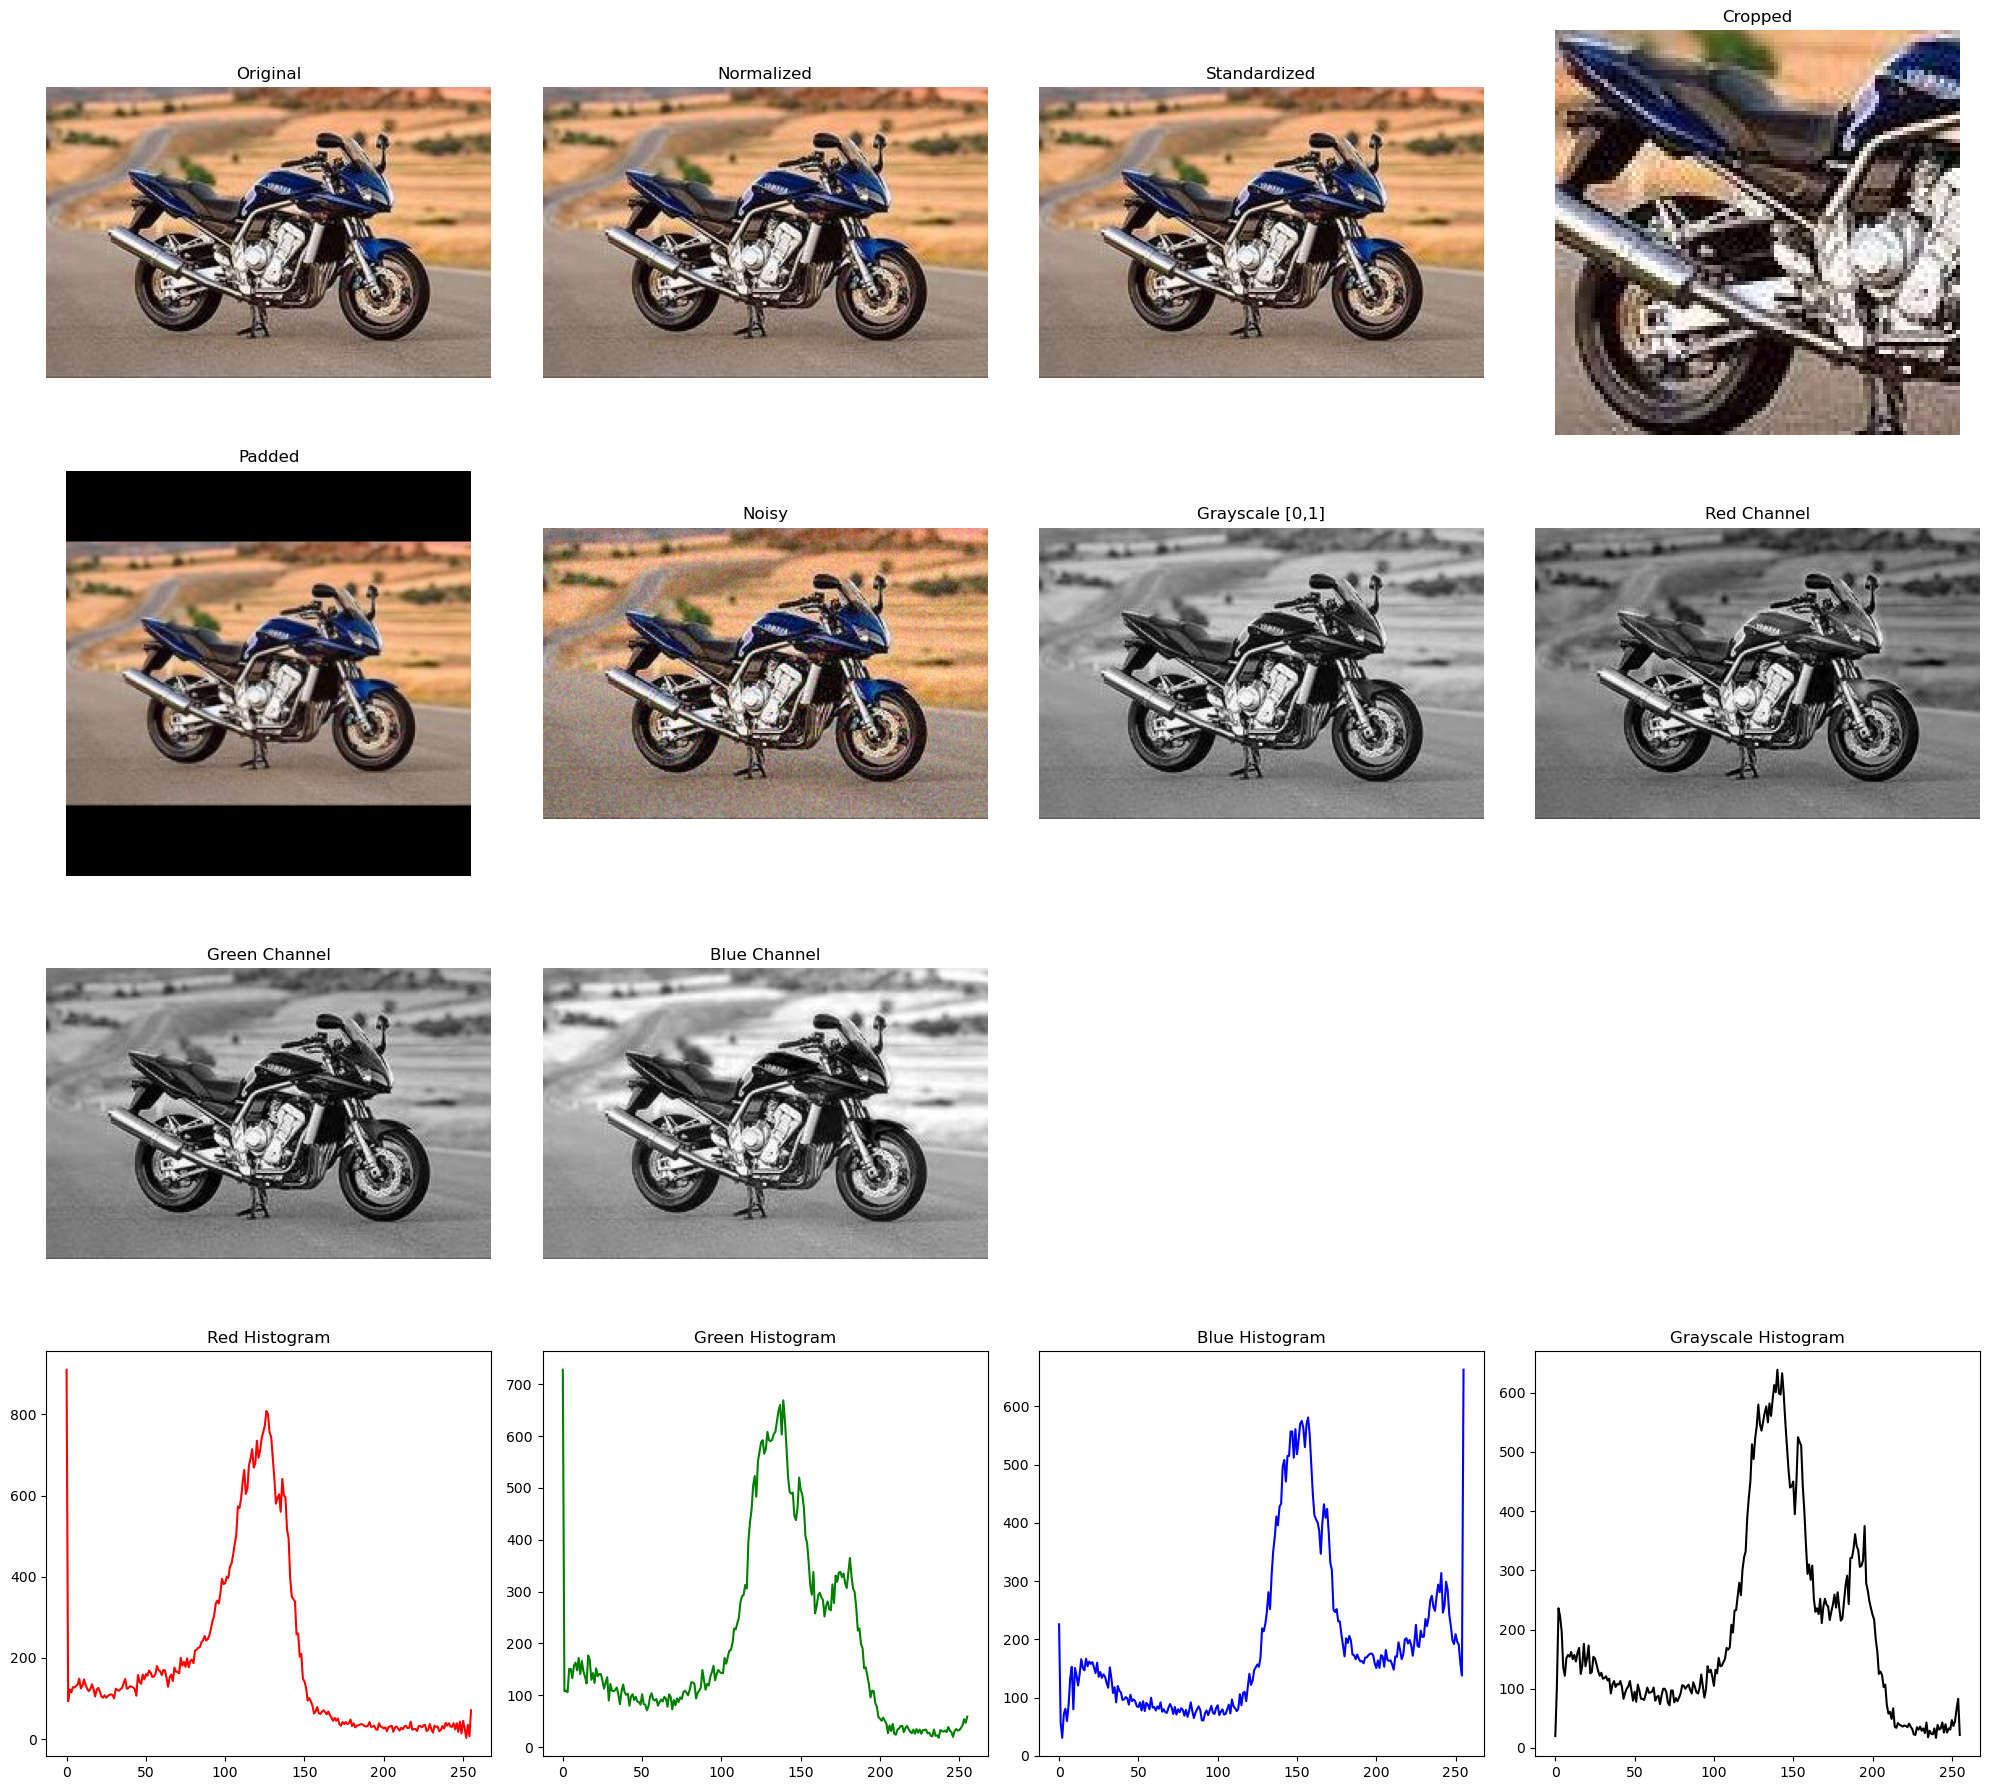

In [185]:
image = load_image("image_0026.jpg")
img_info = inspect_image(image)
print(img_info)

norm_img = min_max_normalize(image)
std_img = standardize(image)

print("After Normalization:")
norm_info = inspect_image(norm_img)
print(norm_info)

print("After Standardization:")
std_info = inspect_image(std_img)
print(std_info)

crop_img = crop_image(image, 50, 50, 100, 100)
print("After Cropping:")
print(inspect_image(crop_img))


pad_img = resize_with_padding(image, (224, 224))
print("After Resizing with Padding:")
print(inspect_image(pad_img))

print("After Adding Gaussian Noise:")
noise_img = add_gaussian_noise(norm_img)
print(inspect_image(noise_img))

gray_img = rgb_to_grayscale(image)
print("After Grayscale Conversion:")
print(inspect_image(gray_img))

red, green, blue = extract_rgb_channels(image)

# Compute separate histograms for the new visualization
def get_single_hist(img):
    # Handle both [0, 255] uint8 and [0, 1] float ranges
    
    if img.dtype != np.uint8:
        h_range = (0, 1)
    else:
        h_range = (0, 256)
    hist,_ = np.histogram(img, bins=256, range=h_range)
    return hist

h_r = get_single_hist(red)
h_g = get_single_hist(green)
h_b = get_single_hist(blue)
h_gray = get_single_hist(gray_img)



fig, axes = plt.subplots(4, 4, figsize=(20, 18))
axes = axes.flatten()


plot_data = [
    (image, "Original", False), 
    (norm_img, "Normalized", False),
    (std_img, "Standardized", False), 
    (crop_img, "Cropped", False),
    (pad_img, "Padded", False), 
    (noise_img, "Noisy", False),
    (gray_img, "Grayscale [0,1]", True), 
    (red, "Red Channel", True),
    (green, "Green Channel", True), 
    (blue, "Blue Channel", True)
]

for i, (img, title, is_gray) in enumerate(plot_data):
    if img is not None:
        # Visual fix for Standardization display
        disp = (img - img.min())/(img.max() - img.min()) if title == "Standardized" else img
        axes[i].imshow(disp, cmap='gray' if is_gray else None)
        axes[i].set_title(title)
    else:
        axes[i].text(0.5, 0.5, f'{title}\nRETURN MISSING', ha='center', color='red')
    axes[i].axis('off')

# --- 4. PLOT HISTOGRAMS ---
# Position 12: Red Hist
axes[12].plot(h_r, color='red')
axes[12].set_title("Red Histogram")

# Position 13: Green Hist
axes[13].plot(h_g, color='green')
axes[13].set_title("Green Histogram")

# Position 14: Blue Hist
axes[14].plot(h_b, color='blue')
axes[14].set_title("Blue Histogram")

# Position 15: Grayscale Hist
axes[15].plot(h_gray, color='black')
axes[15].set_title("Grayscale Histogram")

# Cleanup remaining empty axes
for j in [10, 11]: axes[j].axis('off')

plt.tight_layout()
plt.show()

### Changes observed after Image Processing
Input : 'image_0026.jpg' (A Bike Image)
- Min-Max Normalisation :  (max(1) min(0)) pixel intensity 
- Standardization :  (max(np.float64(2.1825212428053145)), min(np.float64(-2.139017919752859))) pixel intensity
- Cropped Image :  Size changed to 100 x 100 and 'min': np.uint8(0), 'max': np.uint8(255)
- Resize Image with Padding :  Size changed to target 224 x 224, 'min': np.uint8(0), 'max': np.uint8(255)
- Noise : After adding Gaussian Noise 'min': np.float64(-0.1624163181143475), 'max': np.float64(1.1661084086551943) 

In min-max normalised image, slight changes were observed , the picture got stretched slightly\
In Standarised Image, the overall brightness became slightly dull\
In noisy image, there are some gitter pixels observed in the image\


## Tabular Dataset & Preprocessing

In [ ]:
# Allowed Imports for sections below (DO NOT MODIFY)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE

In [ ]:
def load_tabular_dataset(file_path):
    """
    Load the User Disengagement dataset from a CSV file.

    Args:
        file_path (str): Path to the dataset file.

    Returns:
        pd.DataFrame: Loaded dataset.
    """
    # YOUR CODE HERE
    dataframe = pd.read_csv(file_path)
    return dataframe

In [188]:
def inspect_dataset(df, target_column):
    """
    Perform basic inspection of the dataset.

    This function should report:
    - Number of samples
    - Number of features
    - Number of numerical features
    - Number of categorical features
    - Class distribution of the target column

    Args:
        df (pd.DataFrame): Input dataset.
        target_column (str): Name of the target column.

    Returns:
        None
    """
    # YOUR CODE HERE
    row_count = df.shape[0]
    column_count = df.shape[1]
    num_feat = df.select_dtypes(include=[np.number]).shape[1]
    cat_feat = df.select_dtypes(include=['object', 'category']).shape[1]
    class_distribution = df[target_column].describe()

    print(f"Number of samples: {row_count}")
    print(f"Number of features: {column_count}")
    print(f"Number of numerical features: {num_feat}")
    print(f"Number of categorical features: {cat_feat}")
    print(f"Class distribution:\n{class_distribution}")

In [189]:
def impute_missing_values(df):
    """
    Handle missing values in the dataset.

    - Numerical features should be imputed using a statistical strategy
      (e.g., mean or median).
    - Categorical features should be imputed using an appropriate method
      (e.g., mode).

    Args:
        df (pd.DataFrame): Input dataset with missing values.

    Returns:
        pd.DataFrame: Dataset after missing value imputation.
    """
    # YOUR CODE HERE
    df_imputed = df.copy()

    numerical_cols = df_imputed.select_dtypes(include=[np.number]).columns
    categorical_cols = df_imputed.select_dtypes(exclude=[np.number]).columns

    # 1. Numerical Imputation (Median)
    for col in numerical_cols:
        if df_imputed[col].isnull().sum() > 0:
            median_val = df_imputed[col].median()
            df_imputed[col] = df_imputed[col].fillna(median_val)
            
    # 2. Categorical Imputation (Mode)
    for col in categorical_cols:
        if df_imputed[col].isnull().sum() > 0:
            mode_val = df_imputed[col].mode()[0]
            df_imputed[col] = df_imputed[col].fillna(mode_val)
    return df_imputed

### Choice for Imputation of Missing Values
#### Numerical Features
Median Imputation is best suitable because of the following reasons
- It is resistant to outliers
- It preserves the central tendency much better than mean imputation


#### Categorical Features
Mode Imputation is best suitable because of the following reasons
- Replacing the missing values with most frequent fillers preserve the structure of the dataset
- minimises risk of adding unwanted categories to the model



In [190]:
def remove_duplicate_rows(df):
    """
    Detect and remove duplicate rows from the dataset.

    The function should also report the number of duplicate rows removed.

    Args:
        df (pd.DataFrame): Input dataset.

    Returns:
        pd.DataFrame: Dataset after removing duplicates.
    """
    # YOUR CODE HERE
    duplicate_count = df.duplicated().sum()
    df_cleaned = df.drop_duplicates().reset_index(drop=True)
    print(f"Number of duplicate rows removed: {duplicate_count}")
    return df_cleaned


In [ ]:
def perform_eda(df, target_column):
    """
    Perform Exploratory Data Analysis (EDA).

    This function should:
    - Plot the class distribution of the target variable.
    - Plot distributions of at least three important features.
    - Compute and visualize a correlation heatmap for numerical features.

    Args:
        df (pd.DataFrame): Input dataset.
        target_column (str): Name of the target column.

    Returns:
        None
    """
    # YOUR CODE HERE
    fig = plt.figure(figsize=(18, 10))
    grid = plt.GridSpec(2, 3, wspace=0.3, hspace=0.3)

    ax_target = fig.add_subplot(grid[0, 0])
    sns.histplot(df[target_column], kde=True, ax=ax_target, color='royalblue')
    ax_target.set_title(f'Distribution of Target: {target_column}')
    ax_target.set_xlabel(target_column)
    numeric_df = df.select_dtypes(include=['number'])

    if target_column in numeric_df.columns:
        correlations = numeric_df.corr()[target_column].abs().sort_values(ascending=False)
        top_features = correlations.drop(labels=[target_column]).index[:2].tolist()
    else:
        top_features = numeric_df.columns[:2].tolist()

    for i, col in enumerate(top_features):
        ax = fig.add_subplot(grid[0, i + 1])
        sns.kdeplot(df[col], fill=True, ax=ax, color='seagreen')
        ax.set_title(f'Distribution of {col}')
        ax.set_xlabel(col)

    
    ax_heat = fig.add_subplot(grid[1, :])
    corr_matrix = numeric_df.corr()
    sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt=".2f", ax=ax_heat, center=0)
    ax_heat.set_title('Numerical Feature Correlation Heatmap')

    plt.show()



In [ ]:
def detect_and_handle_outliers(df, numerical_columns):
    """
    Detect outliers in numerical features using IQR or Z-score method.

    - Visualize outliers using boxplots.
    - Decide whether to remove or cap outliers.

    Args:
        df (pd.DataFrame): Input dataset.
        numerical_columns (list): List of numerical feature names.

    Returns:
        pd.DataFrame: Dataset after outlier handling.
    """
    # YOUR CODE HERE
    plt.figure(figsize=(15, 5))
    for i, col in enumerate(numerical_columns):
        plt.subplot(1, len(numerical_columns), i + 1)
        sns.boxplot(y=df[col], color='salmon')
        plt.title(f'Outliers in {col}')
    plt.tight_layout()
    plt.show()

    # 2. IQR Calculation and Capping
    df_cleaned = df.copy()
    for col in numerical_columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
      
        df_cleaned[col] = np.clip(df_cleaned[col], lower_bound, upper_bound)
        outliers_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        print(f"Feature '{col}': Capped {outliers_count} outliers.")

    return df_cleaned

In [193]:
def preprocess_features(df, target_column):
    """
    Encode categorical features and normalize numerical features.

    - Categorical variables should be encoded using appropriate techniques.
    - Numerical features should be scaled using Min-Max or Standard Scaling.

    Args:
        df (pd.DataFrame): Input dataset.
        target_column (str): Name of the target column.

    Returns:
        X (np.ndarray): Preprocessed feature matrix.
        y (np.ndarray): Target vector.
    """
    # YOUR CODE HERE
    y = df[target_column].values
    X_raw = df.drop(columns=[target_column])

    numerical_cols = X_raw.select_dtypes(include=[np.number]).columns
    categorical_cols = X_raw.select_dtypes(include=['object', 'category']).columns
    
    scaler = StandardScaler()
    X_num = pd.DataFrame(scaler.fit_transform(X_raw[numerical_cols]), columns=numerical_cols, index=X_raw.index)        
    encoder = OneHotEncoder(sparse_output=False, drop='first')
    X_cat = encoder.fit_transform(X_raw[categorical_cols])
    X_cat = pd.DataFrame(X_cat, index=X_raw.index)

    
    X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1).values

    return X, y

### Justification for using Encoding and Scaling Technique
- One-Hot Encoding : This converts the labels to binary string which is effectively utilised by algorithms without any assumption of order

- Standard Scaler : This technique normalises the numerical values to have a (mean = 0 , std_dev = 1) to become more computationaly inexpensive 

In [194]:
def stratified_split_with_smote(X, y, test_size=0.2, random_state=42):
    """
    Perform a stratified train-test split and apply SMOTE on the training set.

    SMOTE must be applied ONLY on the training data.

    Args:
        X (np.ndarray): Feature matrix.
        y (np.ndarray): Target labels.
        test_size (float): Fraction of data used for testing.
        random_state (int): Random seed.

    Returns:
        X_train_resampled, X_test, y_train_resampled, y_test
    """
    # YOUR CODE HERE
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)
    unique, counts = np.unique(y_train, return_counts=True)
    print(f"Distribution BEFORE SMOTE: {dict(zip(unique, counts))}")

    smote = SMOTE(random_state=random_state)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    unique_res, counts_res = np.unique(y_train_resampled, return_counts=True)
    print(f"Distribution AFTER SMOTE:  {dict(zip(unique_res, counts_res))}")


    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.bar(unique, counts, color=['blue', 'orange'])
    plt.title("Before SMOTE")
    plt.subplot(1, 2, 2)
    plt.bar(unique_res, counts_res, color=['blue', 'orange'])
    plt.title("After SMOTE")
    plt.show()

    return X_train_resampled, X_test, y_train_resampled, y_test

### Table functions visualization and plotting
Create plots of all the operations that you did before in a single plot through the code block below.

### The dataset is split with 80 % Trainset and 20% Test Set

Number of samples: 7043
Number of features: 13
Number of numerical features: 3
Number of categorical features: 10
Class distribution:
count     7043
unique       2
top         No
freq      5174
Name: User Disengagement, dtype: object
Number of duplicate rows removed: 0


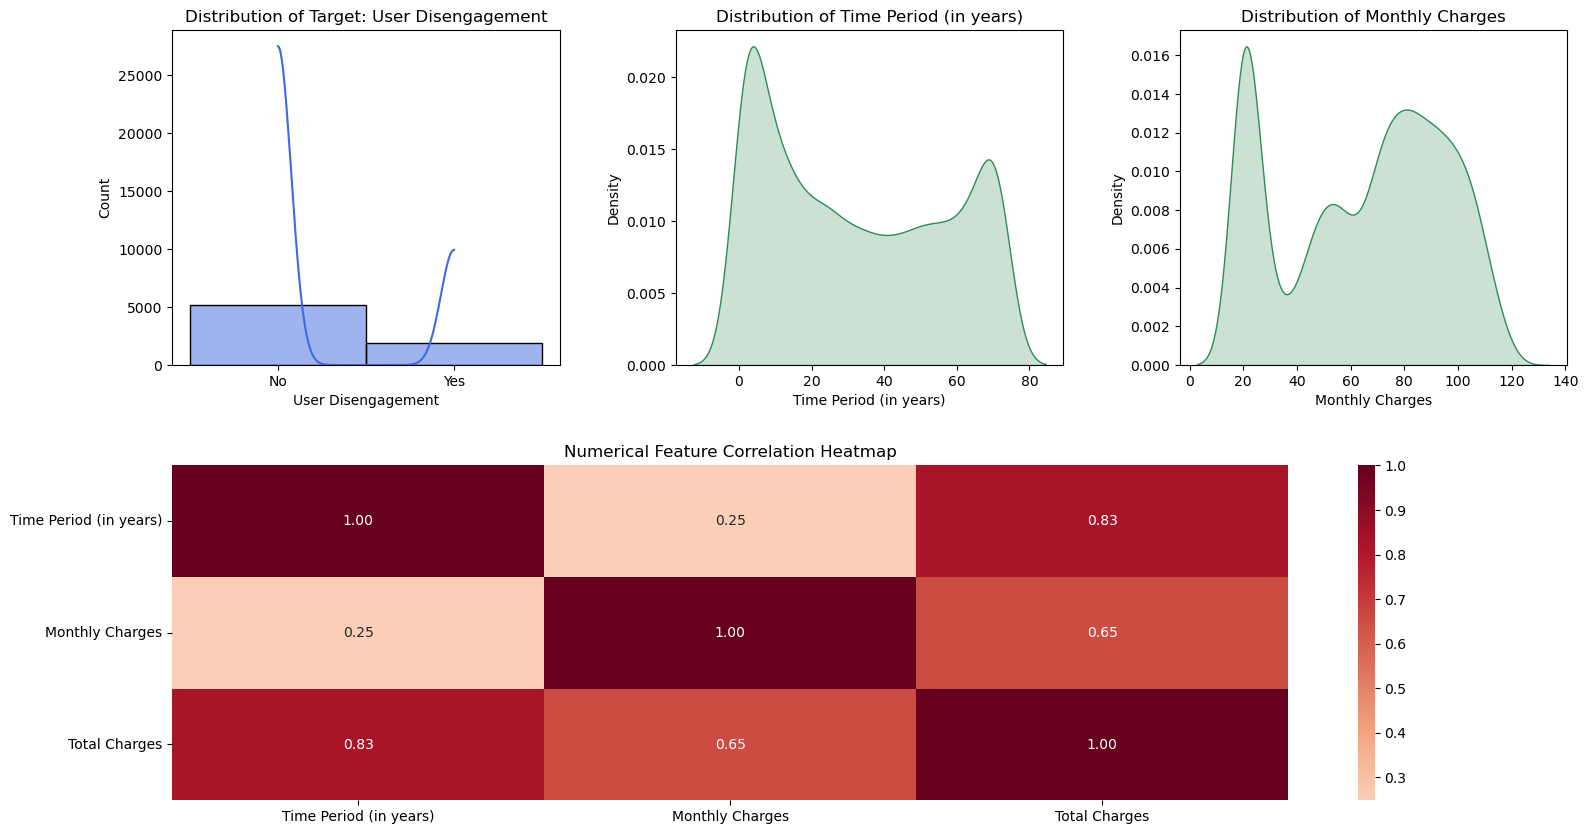

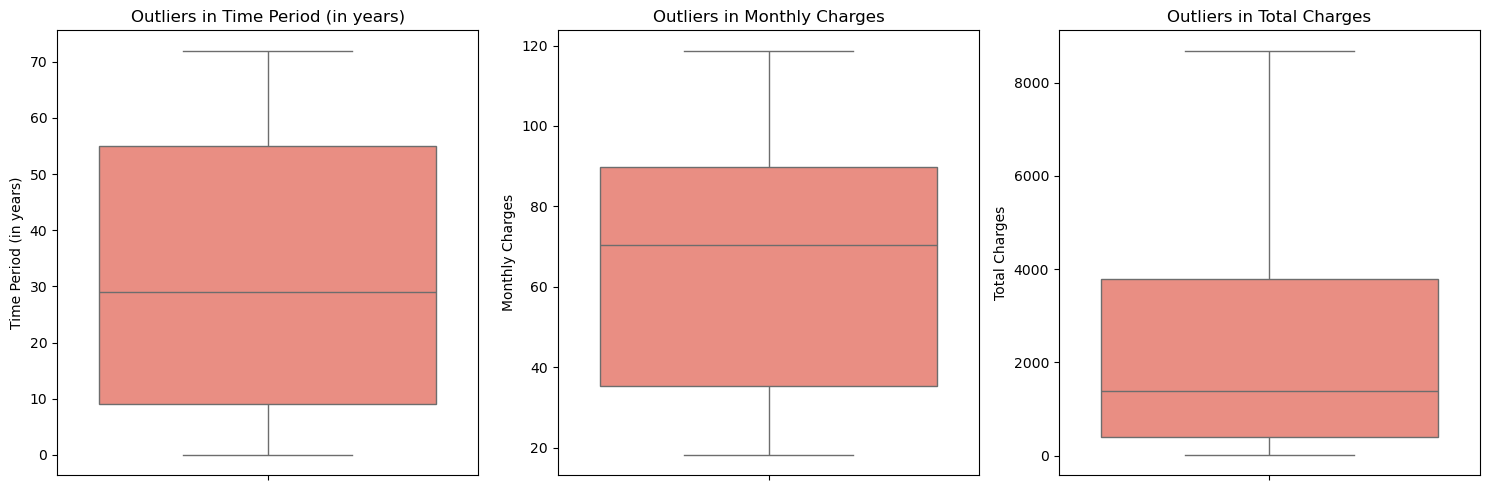

Feature 'Time Period (in years)': Capped 0 outliers.
Feature 'Monthly Charges': Capped 0 outliers.
Feature 'Total Charges': Capped 0 outliers.
Distribution BEFORE SMOTE: {'No': np.int64(4139), 'Yes': np.int64(1495)}
Distribution AFTER SMOTE:  {'No': np.int64(4139), 'Yes': np.int64(4139)}


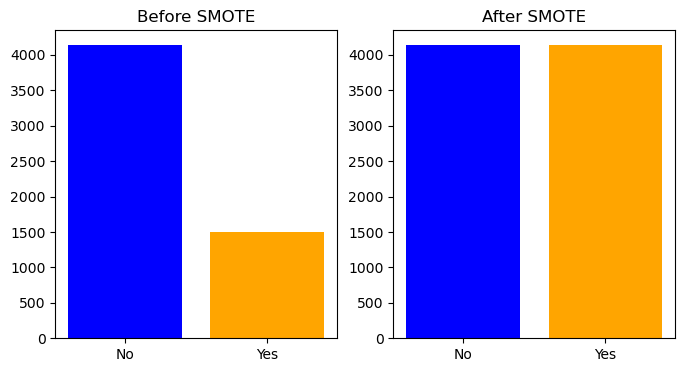

In [195]:
dataset = load_tabular_dataset("User_Disengagement_Dataset.csv")
inspect_dataset(dataset, target_column="User Disengagement")
dataset = impute_missing_values(dataset)
dataset = remove_duplicate_rows(dataset)


perform_eda(dataset, target_column="User Disengagement")
numerical_cols = dataset.select_dtypes(include=[np.number]).columns.tolist()
if "User Disengagement" in numerical_cols:
    numerical_cols.remove("User Disengagement")  # Exclude target column
dataset = detect_and_handle_outliers(dataset, numerical_cols)
X, y = preprocess_features(dataset, target_column="User Disengagement")
X_train_resampled, X_test, y_train_resampled, y_test = stratified_split_with_smote(X, y)



## Linear Regression

In [196]:
def load_dataset(file_path):
    """
    Load the dataset.

    Args:
        file_path (str): Path to the dataset file.

    Returns:
        pd.DataFrame: Loaded dataset.
    """
    # YOUR CODE HERE
    dataframe = pd.read_csv(file_path)
    return dataframe

In [197]:
def explore_regression_dataset(df, target_column):
    """
    Perform initial exploration of the regression dataset.

    This includes:
    - Number of samples and features
    - Number of numerical and categorical features
    - Summary statistics of the target variable

    Args:
        df (pd.DataFrame): Input dataset.
        target_column (str): Target variable name.

    Returns:
        None
    """
    # YOUR CODE HERE
    sample_num = df.shape[0]
    feature_num = df.shape[1] - 1
    num_feat_cnt = df.select_dtypes(include=[np.number]).shape[1]
    cat_feat_cnt = df.select_dtypes(include=['object', 'category']).shape[1]
    target_stats = df[target_column].describe()
    print(f"Number of samples: {sample_num}")
    print(f"Number of features: {feature_num}")
    print(f"Number of numerical features: {num_feat_cnt}")
    print(f"Number of categorical features: {cat_feat_cnt}")
    print(f"Target variable statistics:\n{target_stats}")

In [198]:
def clean_tot_sqft(x):
    # Handle values that are ranges, like "1133 - 1384"
    if(isinstance(x, str)):
        parts = x.split('-')
        if(len(parts) == 2):
            try:
                num1 = float(parts[0].strip())
                num2 = float(parts[1].strip())
                return (num1 + num2) / 2
            except:
                return None
        try:
            return float(x)
        except:
            return None
    return x


def get_bhk(size_string):
    if (pd.isna(size_string)):
        return None
    slices = size_string.split(' ')
    first_slice = slices[0]
    if (first_slice.isdigit()):
        return float(first_slice)
    else:
        return None


def preprocess_regression_data(df, target_column):
    """
     Apply full preprocessing pipeline to the regression dataset.

     This should include:
     - Missing value imputation
     - Duplicate removal
     - Outlier handling
     - Encoding categorical features     
     - Scaling numerical features

     Args:
         df (pd.DataFrame): Input dataset.
         target_column (str): Target variable name.

     Returns:
         X (np.ndarray): Preprocessed features.
         y (np.ndarray): Target values.
     """

    df = df.copy()
    df['total_sqft'] = df['total_sqft'].apply(clean_tot_sqft)
    df['bhk'] = df['size'].apply(get_bhk)

    columns_to_drop = ['area_type', 'society', 'balcony', 'availability']
    df = df.drop(columns_to_drop, axis=1, errors='ignore')
    important_columns = ['total_sqft', 'bhk', 'bath', target_column]
    df = df.dropna(subset=important_columns)
    sqft_per_room = df['total_sqft'] / df['bhk']
    df = df[sqft_per_room >= 300]

    def strip_location(loc):
        return str(loc).strip()
    
    df['location'] = df['location'].apply(strip_location)
    location_counts = df['location'].value_counts()
    
    less_freq_locs = []
    for location, count in location_counts.items():
        if count <= 10:
            less_freq_locs.append(location)

    def cat_location(loc):
        if loc in less_freq_locs:
            return 'other'
        else:
            return loc
            

    df['location'] = df['location'].apply(cat_location)
    df['price_per_sqft'] = df[target_column] * 100000 / df['total_sqft']

    df_clean = pd.DataFrame()

    grouped_data = df.groupby('location')
    
    for location_name, location_df in grouped_data:
        mean_pps = np.mean(location_df['price_per_sqft'])
        std_pps = np.std(location_df['price_per_sqft'])
        lower_limit = mean_pps - std_pps
        upper_limit = mean_pps + std_pps
        
        # Keep rows that are inside this range
        good_rows = location_df[
            (location_df['price_per_sqft'] > lower_limit) & 
            (location_df['price_per_sqft'] <= upper_limit)
        ]
        df_clean = pd.concat([df_clean, good_rows], ignore_index=True)
        
    df = df_clean

    # 9. Select final features and target
    features = ['total_sqft', 'bhk', 'bath', 'location']
    X = df[features]
    y = df[target_column]

    numerical_cols = ['total_sqft', 'bhk', 'bath']
    categorical_cols = ['location']

    preprocessor = ColumnTransformer(
        transformers=[
            ('num_scale', StandardScaler(), numerical_cols),
            ('cat_encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
        ]
    )

    X_processed = preprocessor.fit_transform(X)
    return X_processed, y.values

### Why above processing is done
- In the field ```total_sqft``` there have been ranges instead of numeric values, which was making the category marked as categorical rather orginally being numerical
- In ```size```  the size of the house is measured in BHK but with different notations, ex  4BHK, 4 Bedroom, etc, so we have to strip out of string part to convert this into a numerical feature.
- Dropping High Missing Value Columns, as imputation wont help much
- Dropping missing core feature rows as imputation would add noise

- Core Features for this dataset were found to be ```sqft```, ```bhk```, ```bath```, ```location```
- Grouping less frequent Locations into a one category
- Standardised Scaling of numerical features
- One Hot Encoding for location will


In [199]:
def regression_correlation_analysis(df, target_column):
    """
    Analyze correlation between features and the target variable.

    This function should:
    - Compute correlation coefficients
    - Visualize correlations
    - Comment on multicollinearity

    Args:
        df (pd.DataFrame): Input dataset.
        target_column (str): Target variable name.

    Returns:
        None
    """
    # YOUR CODE HERE
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    correlation_matrix = df[numerical_cols].corr()
    target_correlation = correlation_matrix[target_column].sort_values(ascending=False)

    print("Correlation with target variable:")
    print(target_correlation)

    # Visualize correlation heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
    plt.title('Correlation Matrix - Regression Dataset')
    plt.tight_layout()
    plt.show()

    # Check for multicollinearity
    print("\nMulticollinearity Analysis (excluding target):")
    high_corr_pairs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) > 0.8 and correlation_matrix.columns[j] != target_column:
                high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))

    if high_corr_pairs:
        print("High correlation pairs (>0.8):")
        for pair in high_corr_pairs:
            print(f"  {pair[0]} - {pair[1]}: {pair[2]:.3f}")
    else:
        print("No high multicollinearity detected.")

In [200]:
def split_regression_data(X, y, test_size=0.2, random_state=42):
    """
    Split regression data into training and testing sets.

    Args:
        X (np.ndarray): Feature matrix.
        y (np.ndarray): Target values.
        test_size (float): Fraction used for testing.
        random_state (int): Random seed.

    Returns:
        X_train, X_test, y_train, y_test
    """
    # YOUR CODE HERE
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    return X_train, X_test, y_train, y_test

In [201]:
def train_linear_regression_model(X_train, y_train):
    """
    Train a linear regression model.

    The model may be trained using:
    - Closed-form solution, or
    - A standard machine learning library.

    Args:
        X_train (np.ndarray): Training features.
        y_train (np.ndarray): Training targets.

    Returns:
        model: Trained linear regression model.
    """
    X_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
    X_transpose = X_b.T
    theta_weights = np.linalg.pinv(X_transpose.dot(X_b)).dot(X_transpose).dot(y_train)
    return theta_weights
    

In [202]:
def evaluate_linear_regression(model, X_test, y_test):
    """
    Evaluate the trained linear regression model.

    This function should compute:
    - Mean Squared Error (MSE)
    - Root Mean Squared Error (RMSE)
    - R^2 score

    Args:
        model: Trained regression model.
        X_test (np.ndarray): Test features.
        y_test (np.ndarray): Test targets.

    Returns:
        None
    """
    # YOUR CODE HERE
    X_test_bias = np.c_[np.ones((X_test.shape[0], 1)), X_test]
    pred_Y = X_test_bias.dot(model)
    mean_sqr_error = np.mean((y_test - pred_Y) ** 2)
    root_mean_sq_error = np.sqrt(mean_sqr_error)
    sum_squared_total = np.sum((y_test - np.mean(y_test)) ** 2)
    sum_squared_residual = np.sum((y_test - pred_Y) ** 2)
    r2_score = 1 - (sum_squared_residual / sum_squared_total)
    print(f"Mean Squared Error (MSE): {mean_sqr_error}")
    print(f"Root Mean Squared Error (RMSE): {root_mean_sq_error}")
    print(f"R^2 Score: {r2_score}")
    

In [203]:
def interpret_linear_model_coefficients(model, feature_names):
    """
    Interpret coefficients of the linear regression model.

    Args:
        model: Trained linear regression model.
        feature_names (list): Names of input features.

    Returns:
        None
    """
    # YOUR CODE HERE
    intercept = model[0] # BIAS TERM
    coefficients = model[1:] # WEIGHTS

    if len(coefficients) != len(feature_names): # This would be because of one-hot encoding multiple features will be created for location
        feature_names = []
        for i in range(len(coefficients)):
            feature_names.append(f"Feature_{i+1}")

    data_list = []
    for i, cf in enumerate(coefficients):
        data_list.append({
            'Feature': feature_names[i],
            'Coefficient': cf,
            'Impact': abs(cf)
        })

    df_results = pd.DataFrame(data_list)
    df_results = df_results.sort_values(by='Impact', ascending=False)

    print(f"Base Price (Intercept): {intercept:.2f}\n")
    top_3_features = df_results.head(3)
    
    for _ , row in top_3_features.iterrows():
        feature_name = row['Feature']
        val = row['Coefficient']
        if val > 0:
            direction = "INCREASES"
        else:
            direction = "DECREASES"
        print(f" * {feature_name}:")
        print(f"   Increases in this feature {direction} the price significantly.")
        print(f"   (Coefficient: {val:.4f})\n")

Number of samples: 13320
Number of features: 8
Number of numerical features: 3
Number of categorical features: 6
Target variable statistics:
count    13320.000000
mean       112.565627
std        148.971674
min          8.000000
25%         50.000000
50%         72.000000
75%        120.000000
max       3600.000000
Name: price, dtype: float64
Correlation with target variable:
price      1.000000
bath       0.456345
balcony    0.120355
Name: price, dtype: float64


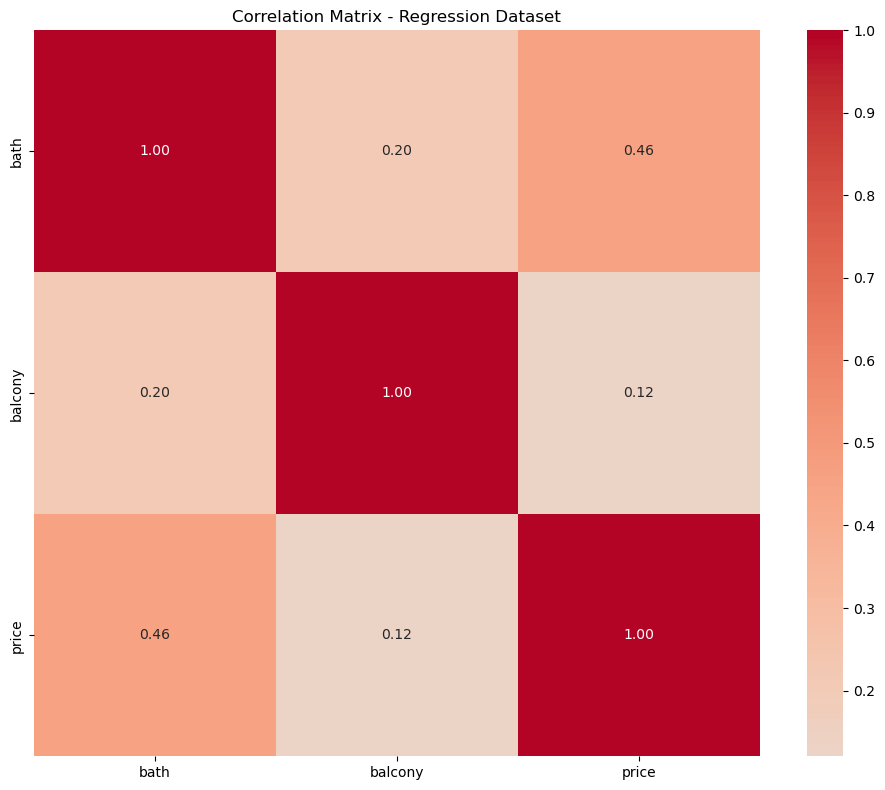


Multicollinearity Analysis (excluding target):
No high multicollinearity detected.
Mean Squared Error (MSE): 2174.4390258175263
Root Mean Squared Error (RMSE): 46.63088060306739
R^2 Score: 0.765660550417855
Base Price (Intercept): 92.91

 * Feature_65:
   Increases in this feature INCREASES the price significantly.
   (Coefficient: 546.7759)

 * Feature_44:
   Increases in this feature INCREASES the price significantly.
   (Coefficient: 185.7965)

 * Feature_186:
   Increases in this feature INCREASES the price significantly.
   (Coefficient: 166.3079)



In [204]:
dataset = load_dataset("House_Price_Dataset.csv")
feature_names = dataset.drop(columns=["price"]).columns.tolist()
explore_regression_dataset(dataset, "price")
regression_correlation_analysis(dataset, "price")
X_cleaned, y_cleaned = preprocess_regression_data(dataset, "price")
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)
weights = train_linear_regression_model(X_train, y_train)
evaluate_linear_regression(weights, X_test, y_test)
interpret_linear_model_coefficients(weights, feature_names)

### Conclusion
The above results are depicting the major impact of different locations impact the price of the housing 
As we have encoded locations part in early data processing, the extra appended features are only from the location categorical variable, so a particular location with ID 65 has been a prime location for the housing price to be higher and ID 44, 186 are following this subsequent pattern